In [53]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam


In [54]:
tf.version.VERSION

'2.19.0'

In [242]:
# Bildgrößen und Pfad definieren
IMAGE_SIZE = (128, 128)
IMAGE_DIRECTORY = "resp_img"

In [243]:
# Funktion zum Einlesen der Bilder und Labels
def load_images_from_directory(directory):
    images = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith('.jpg'):
          # label = filename.split('_')[1].split(".")[0]
          label = filename.split("_")[4].split(".")[0]
        else:
          continue

        label = float(label)

        img = cv2.imread(os.path.join(directory, filename))
        img = cv2.resize(img, IMAGE_SIZE)
        img = img / 255.0

        images.append(img)
        labels.append(label)
    for i in range (len(images)):
       images.append(images[i][:,::-1,:])
       labels.append(180-labels[i])
    return np.array(images), np.array(labels)

In [244]:
def plot_train_history(history):
  plt.plot(history.history['loss'], color='blue')
  plt.plot(history.history['val_loss'], color='red')
  plt.legend(["training loss", "validation loss"])

In [245]:
# Bilder und Labels laden
images, labels = load_images_from_directory(IMAGE_DIRECTORY)
print(images.shape)
labels

(464, 128, 128, 3)


array([111., 124., 117.,  97., 110., 100., 110., 109., 102.,  97.,  92.,
        88.,  78.,  45.,  46.,  50.,  59.,  58.,  52.,  47.,  45.,  45.,
        45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  60.,  65.,
        67.,  79.,  72.,  80.,  69.,  90.,  88.,  95.,  89.,  88.,  90.,
        85.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        48.,  46.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        64.,  64.,  64.,  66.,  66.,  70.,  80.,  63.,  45.,  48.,  54.,
        57.,  56.,  52.,  48.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,  45.,
        45.,  45.,  45.,  50.,  86.,  83., 107., 105., 111., 111., 112.,
       100.,  97.,  83.,  90., 100.,  90.,  90.,  9

In [246]:
labels.min()

np.float64(45.0)

In [247]:
# Durchschnitt der Labelwerte
np.mean(labels)

np.float64(90.0)

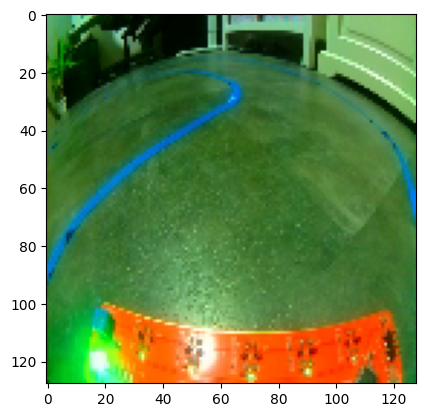

In [248]:
plt.imshow(images[0][:,:,::-1])

In [249]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

In [222]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(24, (5, 5), strides=(2, 2), activation='relu'),
    Conv2D(36, (5, 5),strides=(2, 2), activation='relu'),
    Conv2D(48, (3, 3),strides=(2, 2), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    Dropout(0.2),
    Conv2D(64, (3, 3), activation='relu'),

    Flatten(),
    Dropout(0.2),
    Dense(100, activation='relu'),
    Dense(150, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1)
])

In [250]:
 # Modell für Regression kompilieren
model.compile(optimizer=Adam(learning_rate = 0.001 ), loss='mean_squared_error', metrics=['mae'])

In [251]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [252]:
cp_cb = tf.keras.callbacks.ModelCheckpoint(filepath="cp_model.keras", save_best_only=True, monitor="val_loss", mode="min")

es_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

rp_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)

In [253]:
history = model.fit(images, labels, epochs=100, validation_split=0.2, batch_size=32, callbacks=[cp_cb,es_cb, rp_cb], shuffle=True)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - loss: 4096.1353 - mae: 53.6137 - val_loss: 4366.4380 - val_mae: 60.8843 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 1559.5444 - mae: 32.6364 - val_loss: 3620.2615 - val_mae: 54.8511 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - loss: 1014.7122 - mae: 26.0695 - val_loss: 2310.5891 - val_mae: 43.4925 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 587.8649 - mae: 18.9288 - val_loss: 296.7243 - val_mae: 14.5895 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - loss: 380.2746 - mae: 14.9522 - val_loss: 224.9337 - val_mae: 13.7922 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 246.3637 - mae: 12.0668 - val_loss: 236.8863 - val_mae: 13.7141 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 282.3724 - mae: 12.7169 - val_loss: 130

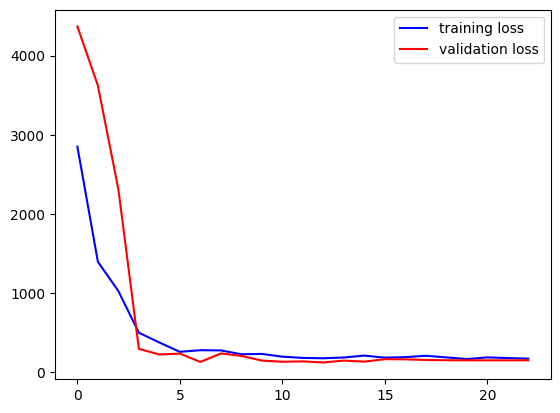

In [254]:
plot_train_history(history)

In [255]:
model.save('my_model.keras') #.keras

In [256]:
loaded_model = tf.keras.models.load_model('my_model.keras')

In [257]:
y_pred = loaded_model.predict(images)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


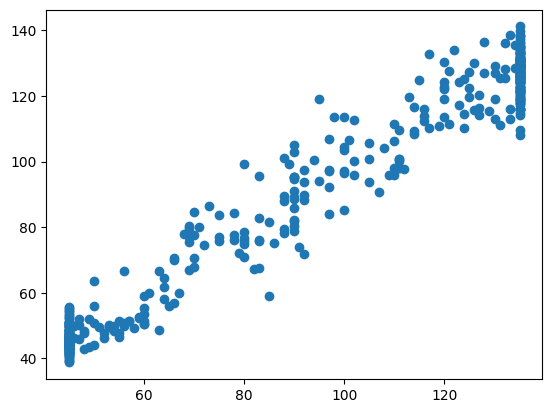

In [258]:
# idealerweise schwanken werte um die Winkelhalbierende
plt.scatter(labels, y_pred)

In [259]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

In [22]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\kaiko\AppData\Local\Temp\tmp8io7foxr\assets


INFO:tensorflow:Assets written to: C:\Users\kaiko\AppData\Local\Temp\tmp8io7foxr\assets


Saved artifact at 'C:\Users\kaiko\AppData\Local\Temp\tmp8io7foxr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2917708622032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2917708624720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2917708623184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2917708627024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2917708627216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2917708624912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2917850775184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2917850772112: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [23]:
with open("TFLite_Modell.tflite", 'wb') as f:
    f.write(tflite_model)

In [24]:
np.__version__

'2.1.3'